# Load and Verify the Research Split

In [38]:

import os
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader 

from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score


In [39]:

# Select GPU if available, otherwise use CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [40]:


DATA_ROOT = Path("/kaggle/input/datasets/francismon/curated-covid19-chest-xray-dataset/dataset")

SPLIT_FILE = Path("/kaggle/input/datasets/jamiulkawsar/curated-covid-chest-x-ray-csv-dataset/data_split.csv")

split_df = pd.read_csv(SPLIT_FILE)

print("Total images:", len(split_df))
print("\nColumns:")
print(split_df.columns.tolist())

print("\nFirst 5 rows:")
display(split_df.head())

Total images: 9208

Columns:
['path', 'label', 'class', 'split']

First 5 rows:


,path,label,class,split
0,train/2_Pneumonia/Pneumonia-Bacterial (1153).jpg,2,2_Pneumonia,train
1,train/0_Normal/Normal (1926).jpg,0,0_Normal,train
2,train/2_Pneumonia/Pneumonia-Viral (364).jpg,2,2_Pneumonia,train
3,train/2_Pneumonia/Pneumonia-Bacterial (973).jpg,2,2_Pneumonia,train
4,train/2_Pneumonia/Pneumonia-Bacterial (280).jpg,2,2_Pneumonia,train


In [41]:
sample_path = DATA_ROOT / split_df.iloc[0]["path"]

print("Sample image path:")
print(sample_path)

print("\nExists:", sample_path.exists())

Sample image path:
/kaggle/input/datasets/francismon/curated-covid19-chest-xray-dataset/dataset/train/2_Pneumonia/Pneumonia-Bacterial (1153).jpg

Exists: True


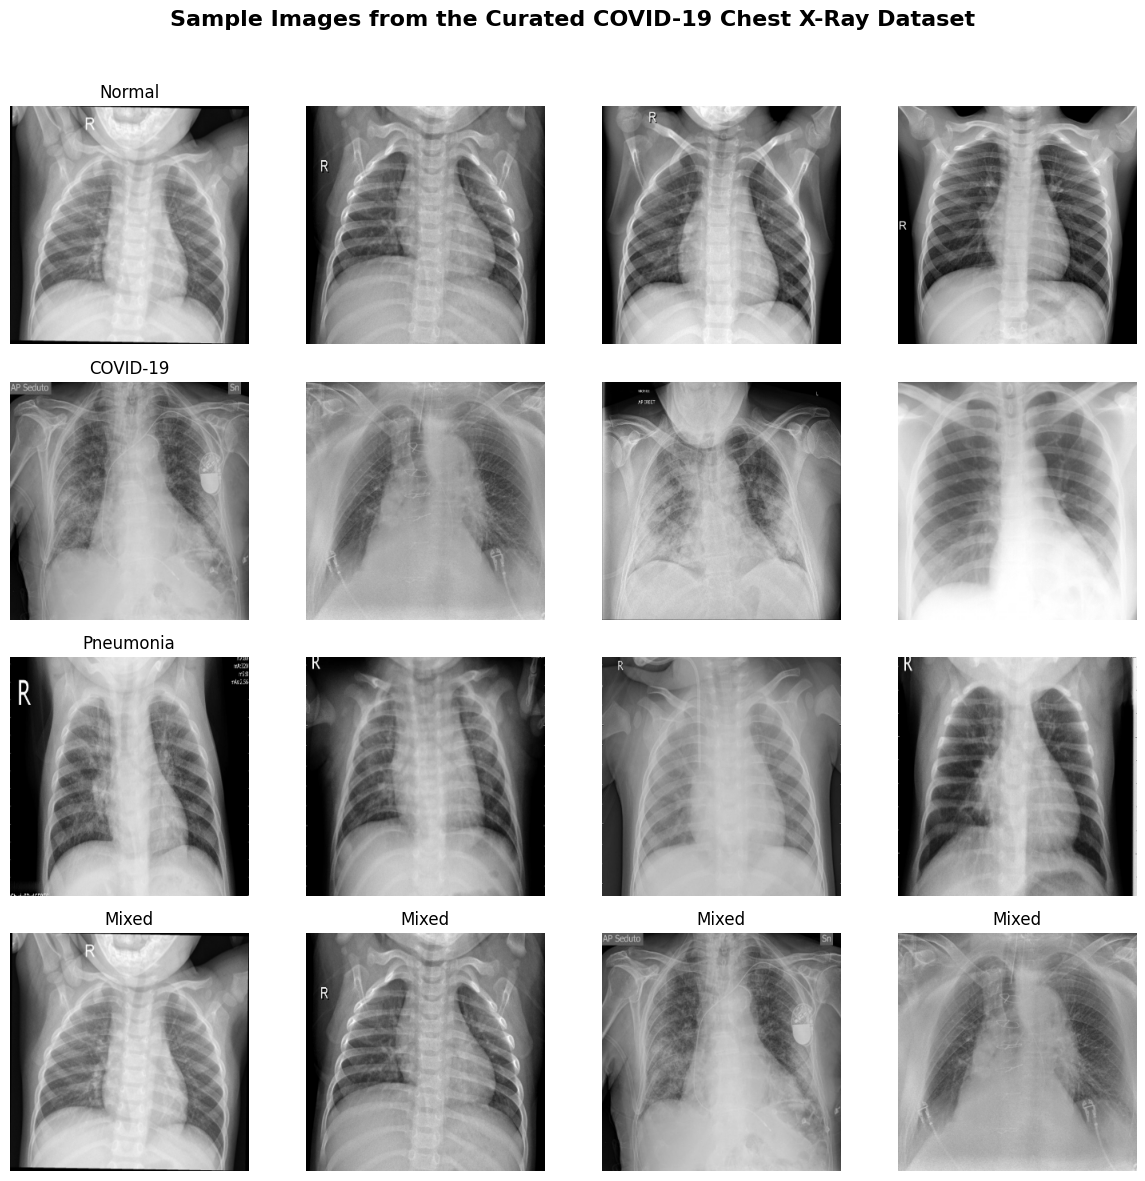

In [42]:

classes = {
    "Normal": "0_Normal",
    "COVID-19": "1_Covid19",
    "Pneumonia": "2_Pneumonia"
}

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

# Main title
fig.suptitle(
    "Sample Images from the Curated COVID-19 Chest X-Ray Dataset",
    fontsize=16,
    fontweight="bold"
)

# First 3 rows: 4 images from each class
for row, (class_name, folder_name) in enumerate(classes.items()):
    image_paths = list(DATA_ROOT.rglob(f"{folder_name}/*.jpg"))[:4]

    for col, image_path in enumerate(image_paths):

        image = Image.open(image_path)

        axes[row, col].imshow(image)
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_title(class_name, fontsize=12)

# Fourth row: mixed images from all 3 classes
mixed_images = []

for folder_name in classes.values():
    mixed_images.extend(list(DATA_ROOT.rglob(f"{folder_name}/*.jpg"))[:2])

for col, image_path in enumerate(mixed_images[:4]):

    image = Image.open(image_path)

    axes[3, col].imshow(image)
    axes[3, col].axis("off")
    axes[3, col].set_title("Mixed", fontsize=12)

# Leave space for the main title
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

# PyTorch Dataset Pipeline

In [43]:
# create the pytorch dataset

class ChestXRayDataset(Dataset):

  def __init__(self, dataframe, data_root, transform = None):
    self.dataframe = dataframe.reset_index(drop = True)
    self.data_root = Path(data_root)
    self.transform = transform

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, index):
    row = self.dataframe.iloc[index]

    image_path = self.data_root / row["path"]
    label = int(row["label"])

    image = Image.open(image_path).convert("RGB")
    if self.transform:
      image = self.transform(image)

    return image, label


In [44]:
# craete the three obj
train_data = split_df[split_df["split"] == "train"]
val_data = split_df[split_df["split"] == "validation"]
test_data = split_df[split_df["split"] == "test"]

train_dataset = ChestXRayDataset(train_data, DATA_ROOT)
val_dataset = ChestXRayDataset(val_data, DATA_ROOT)
test_dataset = ChestXRayDataset(test_data, DATA_ROOT)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 6445
Validation: 1381
Test: 1382


In [45]:
image, label = train_dataset[0]

print("Image type:", type(image))
print("Image size:", image.size)
print("Label:", label)

Image type: <class 'PIL.Image.Image'>
Image size: (299, 299)
Label: 2


 # Image Preprocessing & Data Augmentation

In [46]:
#Create the transform definitions

IMAGE_SIZE = 224
IMAGE_MEAN = [0.485, 0.456, 0.406]
IMAGE_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.RandomRotation(degrees = 10),
    transforms.ToTensor(),
    transforms.Normalize(mean = IMAGE_MEAN, std = IMAGE_STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean = IMAGE_MEAN, std = IMAGE_STD)
])

In [47]:
#Recreate the datasets
train_dataset = ChestXRayDataset(
    train_data,
    DATA_ROOT,
    transform = train_transform
)

val_dataset = ChestXRayDataset(
    val_data,
    DATA_ROOT,
    transform = val_test_transform
)

test_dataset = ChestXRayDataset(
    test_data,
    DATA_ROOT,
    transform = val_test_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))
#

Train: 6445
Validation: 1381
Test: 1382


In [48]:
#Test one sample
image, label = train_dataset[0]

print("Image type:", type(image))
print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Label:", label)

Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 224, 224])
Image dtype: torch.float32
Label: 2


# PyTorch DataLoaders

In [49]:
# Create DataLoaders

BATCH_SIZE = 32


#train loader
train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 2
)

# validation loader
val_loader = DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 2
)

# test loader
test_loader = DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 2
)

In [50]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([2, 0, 2, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 1, 2, 2, 2, 0, 0, 1, 0, 2, 2,
        1, 2, 0, 0, 2, 2, 0, 2])
Image dtype: torch.float32
Label dtype: torch.int64


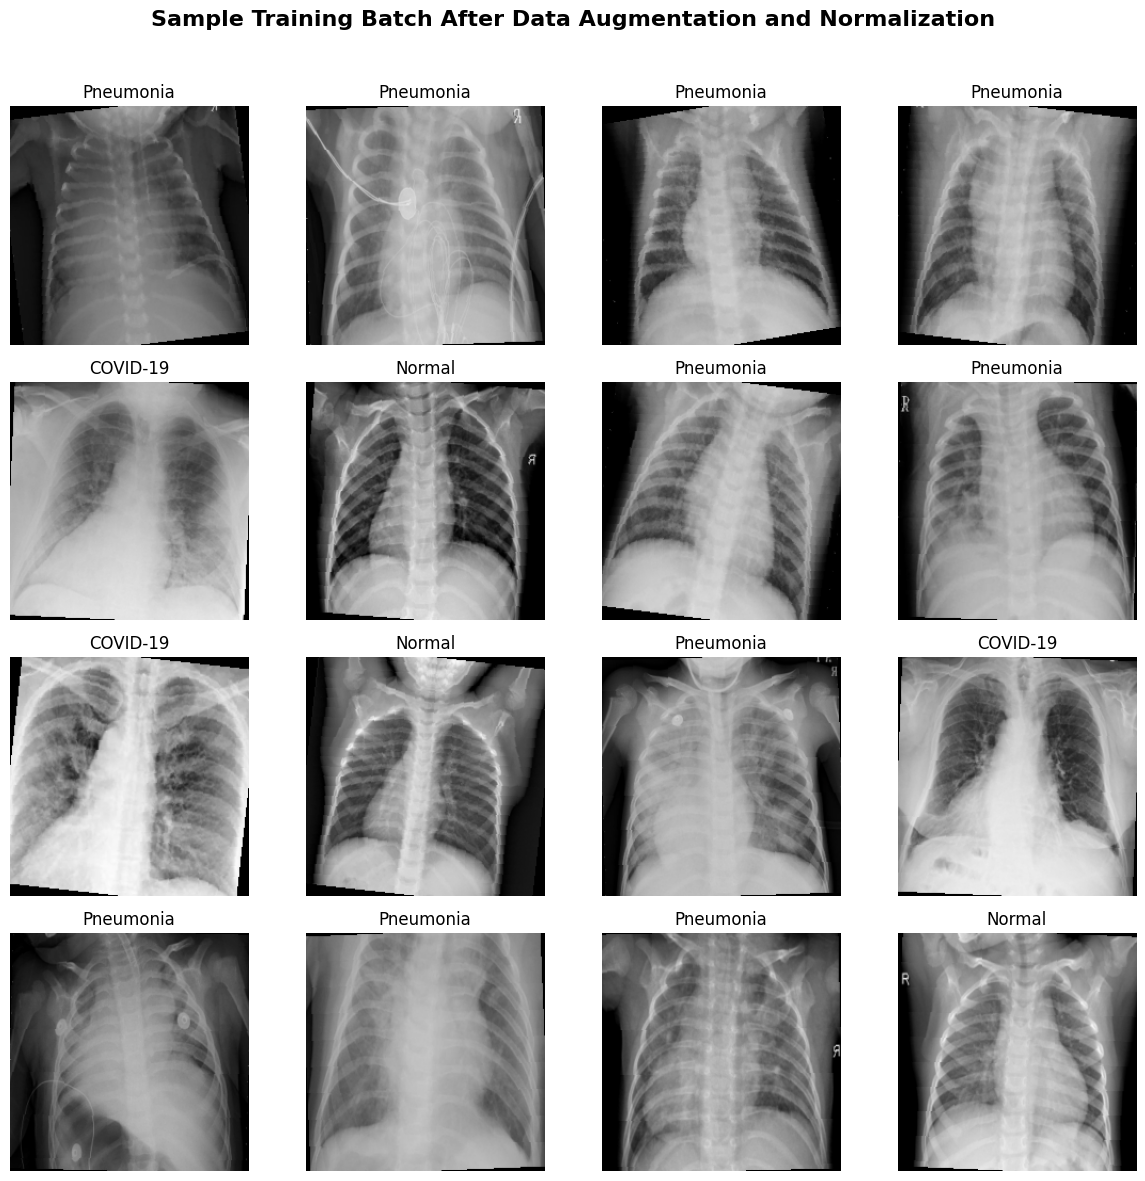

In [51]:

# Get one batch from the training DataLoader
images, labels = next(iter(train_loader))

# ImageNet normalization values
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# Create 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

# Main title
fig.suptitle(
    "Sample Training Batch After Data Augmentation and Normalization",
    fontsize=16,
    fontweight="bold"
)

for i, ax in enumerate(axes.flat):

    image = images[i]

    # Undo normalization for visualization
    image = image * std + mean
    image = torch.clamp(image, 0, 1)

    # [C, H, W] → [H, W, C]
    image = image.permute(1, 2, 0)

    # Display image
    ax.imshow(image)
    ax.axis("off")

    # Class name
    class_names = ["Normal", "COVID-19", "Pneumonia"]
    ax.set_title(class_names[labels[i].item()])

# Leave space for the main title
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

# Custom CNN Baseline

In [52]:
import torch.nn as nn

In [53]:

class CustomCNN(nn.Module):
    """
    Simple convolutional neural network baseline for
    3-class chest X-ray classification.

    Classes:
        0 -> Normal
        1 -> COVID-19
        2 -> Pneumonia
    """

    def __init__(self, num_classes=3):
        super().__init__()

        # Feature extraction
        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Global Average Pooling
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Classification head
        self.classifier = nn.Linear(
            in_features=128,
            out_features=num_classes
        )

    def forward(self, x):

        # Extract visual features
        x = self.features(x)

        # [batch, 128, 1, 1]
        # -> [batch, 128]
        x = torch.flatten(x, start_dim=1)

        # Classification logits
        x = self.classifier(x)

        return x

In [54]:
# =========================
# Experiment Configuration
# =========================

SEED = 42

IMAGE_SIZE = 224
BATCH_SIZE = 32

NUM_CLASSES = 3
LEARNING_RATE = 0.001
NUM_EPOCHS = 50

CLASS_NAMES = [
    "Normal",
    "COVID-19",
    "Pneumonia"
]

MODEL_NAME = "CustomCNN"

print("Model:", MODEL_NAME)
print("Number of classes:", NUM_CLASSES)
print("Learning rate:", LEARNING_RATE)
print("Batch size:", BATCH_SIZE)
print("Number of epochs:", NUM_EPOCHS)

Model: CustomCNN
Number of classes: 3
Learning rate: 0.001
Batch size: 32
Number of epochs: 50


In [55]:
model = CustomCNN(num_classes=NUM_CLASSES).to(device)

print(model)
print("\nModel device:", next(model.parameters()).device)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Linear(in_features=128, out_features=3, bias=True)
)

Model device: cuda:0


In [56]:
#loss function
criterion = nn.CrossEntropyLoss()

print("Loss function:", criterion)

Loss function: CrossEntropyLoss()


In [57]:
#optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Optimizer: Adam")
print("Learning rate:", LEARNING_RATE)

Optimizer: Adam
Learning rate: 0.001


In [58]:
# Create a fresh model for the actual baseline experiment
model = CustomCNN(num_classes=NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Fresh model created.")
print("Device:", next(model.parameters()).device)

Fresh model created.
Device: cuda:0


In [59]:
# =========================
# Training Configuration
# =========================

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []


best_val_loss = float("inf")
best_model_path = "/kaggle/working/best_custom_cnn.pth"

# =========================
# Training Loop
# =========================

for epoch in range(NUM_EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # Move data to device
        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        # Track loss
        running_loss += loss.item() * images.size(0)

        # Predictions
        predictions = outputs.argmax(dim=1)

        # Track accuracy
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    # Epoch training metrics
    train_loss = running_loss / total
    train_accuracy = correct / total


    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            # Move data to device
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Track loss
            val_running_loss += loss.item() * images.size(0)

            # Predictions
            predictions = outputs.argmax(dim=1)

            # Track accuracy
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    # Epoch validation metrics
    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total


    # -------------------------
    # Store metrics
    # -------------------------
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)


    # -------------------------
    # Print epoch results
    # -------------------------
    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy:.4f}"
    )
    # check point 
    if val_loss < best_val_loss:
      best_val_loss = val_loss

      torch.save(
          model.state_dict(),
          best_model_path
      )

      print("Best model saved.")

Epoch [1/50] | Train Loss: 0.8725 | Train Acc: 0.5910 | Val Loss: 0.6678 | Val Acc: 0.7712
Best model saved.
Epoch [2/50] | Train Loss: 0.6525 | Train Acc: 0.7404 | Val Loss: 0.5559 | Val Acc: 0.7813
Best model saved.
Epoch [3/50] | Train Loss: 0.4924 | Train Acc: 0.8174 | Val Loss: 0.4896 | Val Acc: 0.7726
Best model saved.
Epoch [4/50] | Train Loss: 0.3936 | Train Acc: 0.8532 | Val Loss: 0.4220 | Val Acc: 0.8277
Best model saved.
Epoch [5/50] | Train Loss: 0.3576 | Train Acc: 0.8670 | Val Loss: 0.3131 | Val Acc: 0.8878
Best model saved.
Epoch [6/50] | Train Loss: 0.3075 | Train Acc: 0.8861 | Val Loss: 0.5604 | Val Acc: 0.8161
Epoch [7/50] | Train Loss: 0.3184 | Train Acc: 0.8846 | Val Loss: 0.4109 | Val Acc: 0.8487
Epoch [8/50] | Train Loss: 0.2931 | Train Acc: 0.8909 | Val Loss: 0.4086 | Val Acc: 0.8262
Epoch [9/50] | Train Loss: 0.2737 | Train Acc: 0.9002 | Val Loss: 0.2784 | Val Acc: 0.8965
Best model saved.
Epoch [10/50] | Train Loss: 0.2625 | Train Acc: 0.9038 | Val Loss: 0.2544

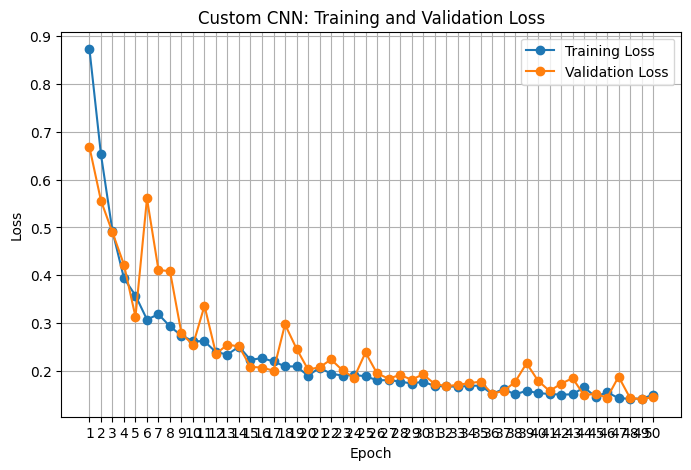

In [60]:
#Plot training and validation loss
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN: Training and Validation Loss")

plt.xticks(epochs)
plt.legend()
plt.grid(True)


plt.savefig(
    "custom_cnn_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

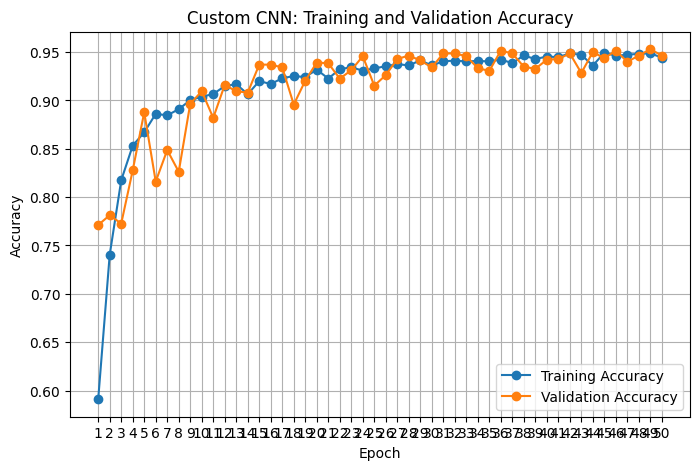

In [61]:
# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN: Training and Validation Accuracy")

plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.savefig(
    "custom_cnn_training_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [62]:

print("Current working directory:")
print(os.getcwd())

print("\nCheckpoint path:")
print(os.path.abspath(best_model_path))
print(os.listdir("/kaggle/working"))

Current working directory:
/kaggle/working

Checkpoint path:
/kaggle/working/best_custom_cnn.pth
['custom_cnn_training_accuracy.png', 'custom_cnn_training_loss.png', 'custom_cnn_roc_curve.png', 'best_custom_cnn.pth', '.virtual_documents']


In [63]:
# =========================
# Load Best Custom CNN
# =========================

model.load_state_dict(
    torch.load(
        "/kaggle/working/best_custom_cnn.pth",
        map_location=device
    )
)

model = model.to(device)

model.eval()

print("Best Custom CNN checkpoint loaded.")

Best Custom CNN checkpoint loaded.


In [64]:
# =========================
# Final Test Evaluation
# =========================

model.eval()

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_loss = test_loss / total
test_accuracy = correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Samples: {total}")

Test Loss: 0.1368
Test Accuracy: 0.9522
Test Accuracy: 95.22%
Test Samples: 1382


In [65]:
# =========================
# Confusion Matrix
# =========================

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

report = classification_report(
    all_labels,
    all_predictions,
    target_names=CLASS_NAMES,
    digits=4
)

print(report)

              precision    recall  f1-score   support

      Normal     0.9207    0.9695    0.9444       491
    COVID-19     0.9674    0.9271    0.9468       192
   Pneumonia     0.9721    0.9471    0.9594       699

    accuracy                         0.9522      1382
   macro avg     0.9534    0.9479    0.9502      1382
weighted avg     0.9532    0.9522    0.9523      1382



In [66]:
# =========================
# Specificity for Each Class
# =========================

import numpy as np

cm = confusion_matrix(all_labels, all_predictions)

specificity = []

for i in range(len(CLASS_NAMES)):
    true_negative = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
    false_positive = np.sum(cm[:, i]) - cm[i, i]

    spec = true_negative / (true_negative + false_positive)
    specificity.append(spec)

for class_name, spec in zip(CLASS_NAMES, specificity):
    print(f"{class_name}: {spec:.4f} ({spec * 100:.2f}%)")

Normal: 0.9540 (95.40%)
COVID-19: 0.9950 (99.50%)
Pneumonia: 0.9722 (97.22%)


In [67]:
# =========================
# Collect Test Probabilities
# =========================

model.eval()

all_probabilities = []
all_labels_auc = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        all_labels_auc.extend(
            labels.numpy()
        )

all_probabilities = np.array(all_probabilities)
all_labels_auc = np.array(all_labels_auc)

print("Probability shape:", all_probabilities.shape)
print("Labels shape:", all_labels_auc.shape)

Probability shape: (1382, 3)
Labels shape: (1382,)


Normal ROC-AUC: 0.9926
COVID-19 ROC-AUC: 0.9981
Pneumonia ROC-AUC: 0.9915
Macro ROC-AUC: 0.9941


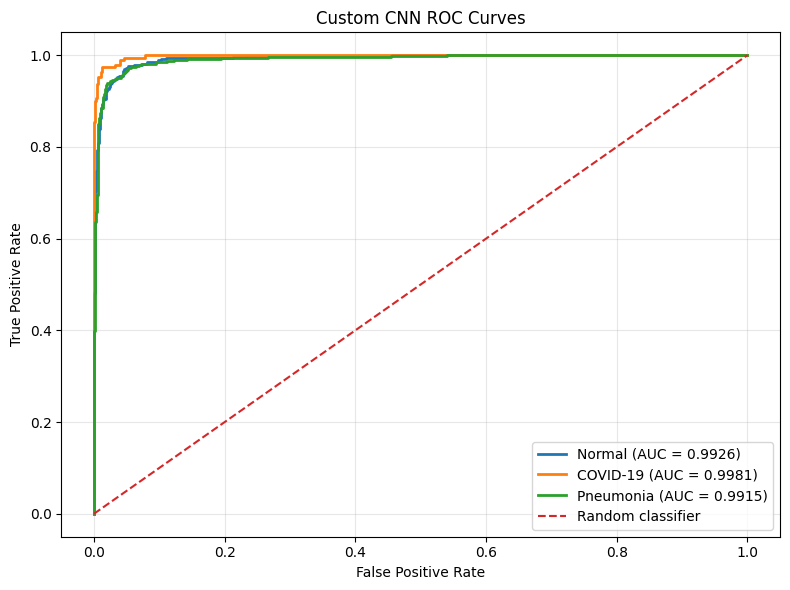

In [68]:
# =========================
# ROC Curve and AUC
# =========================



# Binarize the true labels
y_true = label_binarize(
    all_labels_auc,
    classes=[0, 1, 2]
)

# Calculate ROC curve for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(NUM_CLASSES):

    fpr[i], tpr[i], _ = roc_curve(
        y_true[:, i],
        all_probabilities[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

# Macro-average ROC-AUC
macro_auc = roc_auc_score(
    all_labels_auc,
    all_probabilities,
    multi_class="ovr",
    average="macro"
)

# Print AUC values
for i, class_name in enumerate(CLASS_NAMES):
    print(
        f"{class_name} ROC-AUC: "
        f"{roc_auc[i]:.4f}"
    )

print(f"Macro ROC-AUC: {macro_auc:.4f}")


# =========================
# Plot ROC Curves
# =========================

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(CLASS_NAMES):

    plt.plot(
        fpr[i],
        tpr[i],
        linewidth=2,
        label=f"{class_name} (AUC = {roc_auc[i]:.4f})"
    )

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Custom CNN ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()

# Save figure
plt.savefig(
    "/kaggle/working/custom_cnn_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [69]:

print("Current working directory:")
print(os.getcwd())

print("\nCheckpoint path:")
print(os.path.abspath(best_model_path))
print(os.listdir("/kaggle/working"))

Current working directory:
/kaggle/working

Checkpoint path:
/kaggle/working/best_custom_cnn.pth
['custom_cnn_training_accuracy.png', 'custom_cnn_training_loss.png', 'custom_cnn_roc_curve.png', 'best_custom_cnn.pth', '.virtual_documents']
